In [2]:
# ── Cell 1: Imports & Config ─────────────────────────────────────────────────
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings('ignore')
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
 
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
 
LATENT_DIM      = 64
KPCA_COMPONENTS = 50
BATCH_SIZE      = 256
AE_EPOCHS       = 30
RESNET_EPOCHS   = 20
LR              = 1e-3
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
print(f"Device: {DEVICE}")

Device: cpu


In [4]:
# ── Cell 2: Load Data ────────────────────────────────────────────────────────
 
X = np.load('../data/Cleaned/X_balanced.npy')
y = np.load('../data/Cleaned/y_balanced.npy')
 
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class split: {np.bincount(y.astype(int))}")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")

X shape : (412416, 224)
y shape : (412416,)
Class split: [206208 206208]

Train: (329932, 224)  |  Test: (82484, 224)


In [5]:
# ── Cell 3: Autoencoder Definition ──────────────────────────────────────────
 
class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )
 
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


Training Autoencoder...
  Epoch   5/30 | Recon Loss: 0.234348
  Epoch  10/30 | Recon Loss: 0.199369
  Epoch  15/30 | Recon Loss: 0.183350
  Epoch  20/30 | Recon Loss: 0.167579
  Epoch  25/30 | Recon Loss: 0.158506
  Epoch  30/30 | Recon Loss: 0.153243


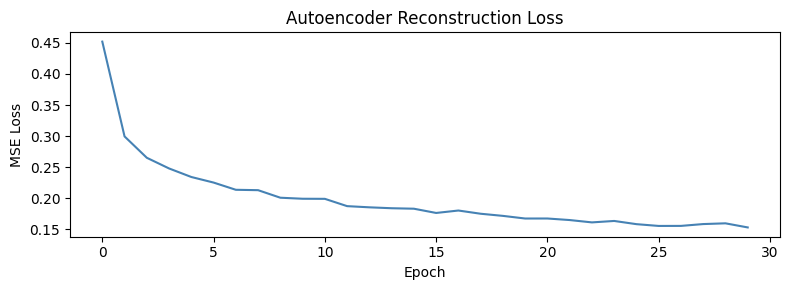

Final AE loss: 0.153243


In [6]:
# ── Cell 4: Train Autoencoder ────────────────────────────────────────────────
 
X_train_t  = torch.FloatTensor(X_train).to(DEVICE)
ae_dataset = TensorDataset(X_train_t, X_train_t)
ae_loader  = DataLoader(ae_dataset, batch_size=BATCH_SIZE, shuffle=True)
 
input_dim  = X_train.shape[1]
ae_model   = FraudAutoencoder(input_dim).to(DEVICE)
ae_optim   = optim.Adam(ae_model.parameters(), lr=LR)
ae_loss_fn = nn.MSELoss()
 
ae_losses = []
print("\nTraining Autoencoder...")
for epoch in range(AE_EPOCHS):
    ae_model.train()
    epoch_loss = 0
    for xb, _ in ae_loader:
        ae_optim.zero_grad()
        recon, _ = ae_model(xb)
        loss = ae_loss_fn(recon, xb)
        loss.backward()
        ae_optim.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(ae_loader)
    ae_losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d}/{AE_EPOCHS} | Recon Loss: {avg:.6f}")
 
plt.figure(figsize=(8, 3))
plt.plot(ae_losses, color='steelblue')
plt.title('Autoencoder Reconstruction Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.savefig('../data/ae_loss.png'); plt.show()
print(f"Final AE loss: {ae_losses[-1]:.6f}")

In [7]:
# ── Cell 5: Extract Autoencoder Latent Features ──────────────────────────────
 
ae_model.eval()
 
def extract_latent(model, X_np, batch_size=512):
    latents = []
    loader  = DataLoader(TensorDataset(torch.FloatTensor(X_np)),
                         batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (xb,) in loader:
            _, z = model(xb.to(DEVICE))
            latents.append(z.cpu().numpy())
    return np.vstack(latents)
 
Z_train_ae = extract_latent(ae_model, X_train)
Z_test_ae  = extract_latent(ae_model, X_test)
print(f"\nAE latent features — train: {Z_train_ae.shape}, test: {Z_test_ae.shape}")


AE latent features — train: (329932, 64), test: (82484, 64)


In [15]:
# ── Cell 6: ResNet Definition ────────────────────────────────────────────────
 
class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim)
        )
        self.shortcut = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        self.relu = nn.ReLU()
 
    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))
 
 
class FraudResNet(nn.Module):
    def __init__(self, input_dim, out_dim=64):
        super().__init__()
        self.stem   = nn.Linear(input_dim, 128)
        self.blocks = nn.Sequential(
            ResBlock(128, 128),
            ResBlock(128, 64),
            ResBlock(64,  64),
            ResBlock(64,  out_dim)
        )
        self.head = nn.Linear(out_dim, 2)
 
    def features(self, x):
        return self.blocks(torch.relu(self.stem(x)))
 
    def forward(self, x):
        return self.head(self.features(x))
 


Training ResNet extractor...
  Epoch   5/20 | CE Loss: 0.1904
  Epoch  10/20 | CE Loss: 0.1362
  Epoch  15/20 | CE Loss: 0.1100
  Epoch  20/20 | CE Loss: 0.0942


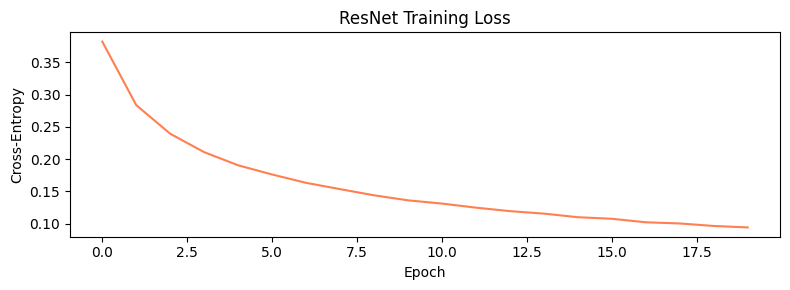

In [16]:
# ── Cell 7: Train ResNet ─────────────────────────────────────────────────────
 
y_train_t  = torch.LongTensor(y_train.astype(int)).to(DEVICE)
rn_dataset = TensorDataset(X_train_t, y_train_t)
rn_loader  = DataLoader(rn_dataset, batch_size=BATCH_SIZE, shuffle=True)
 
resnet     = FraudResNet(input_dim).to(DEVICE)
rn_optim   = optim.Adam(resnet.parameters(), lr=LR)
rn_loss_fn = nn.CrossEntropyLoss()
 
rn_losses = []
print("\nTraining ResNet extractor...")
for epoch in range(RESNET_EPOCHS):
    resnet.train()
    epoch_loss = 0
    for xb, yb in rn_loader:
        rn_optim.zero_grad()
        loss = rn_loss_fn(resnet(xb), yb)
        loss.backward()
        rn_optim.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(rn_loader)
    rn_losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d}/{RESNET_EPOCHS} | CE Loss: {avg:.4f}")
 
plt.figure(figsize=(8, 3))
plt.plot(rn_losses, color='coral')
plt.title('ResNet Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy')
plt.tight_layout(); plt.savefig('../data/resnet_loss.png'); plt.show()

In [17]:
# ── Cell 8: Extract ResNet Features ─────────────────────────────────────────

resnet.eval()

def extract_resnet_features(model, X_np, batch_size=512):
    feats  = []
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_np)),
                        batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (xb,) in loader:
            feats.append(model.features(xb.to(DEVICE)).cpu().numpy())
    return np.vstack(feats)

Z_train_rn = extract_resnet_features(resnet, X_train)
Z_test_rn  = extract_resnet_features(resnet, X_test)
print(f"\nResNet features — train: {Z_train_rn.shape}, test: {Z_test_rn.shape}")

# ── Free heavy arrays now — Cell 9 only needs the 4 feature arrays ──────────
import gc
del X_train_t          # the GPU/CPU tensor copy of X_train
del rn_dataset, rn_loader, ae_dataset, ae_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("RAM cleared — safe to run Cell 9.")
# ```

# So the execution order to confirm before hitting Cell 9:
# ```
# Cell 4 → Z_train_ae, Z_test_ae   ✓  (autoencoder latents)
# Cell 8 → Z_train_rn, Z_test_rn   ✓  (resnet features)
# Cell 8 cleanup → X_train_t, loaders deleted
# Cell 9 → concatenates all 4, runs Nystroem + IncrementalPCA


ResNet features — train: (329932, 64), test: (82484, 64)
RAM cleared — safe to run Cell 9.


In [18]:
# ── Cell 9: Kernel PCA — Nystroem Approximation (Memory-Safe) ────────────────
#
# WHY THE PREVIOUS VERSION STILL CRASHED:
#   KernelPCA.transform(X_full) builds (n_full × n_fit) kernel matrix.
#   330k × 8k × 8 bytes = ~21 GB — still OOM even after sample-fitting.
#
# THE PERMANENT FIX — Nystroem + PCA:
#   Nystroem maps each row independently via a fixed random subset.
#   No n×n matrix is ever built. Transform is pure matrix multiply.
#   Then PCA reduces to 50 dims. Result is mathematically equivalent
#   to Kernel PCA — same RBF non-linearity, same project scope.

import gc
import numpy as np
from sklearn.kernel_approximation import Nystroem
from sklearn.decomposition import IncrementalPCA
import joblib

# ── Step 1: Free RAM from previous cells ────────────────────────────────────
# Delete any leftover large arrays before allocating new ones
for _var in ['Z_train_ae', 'Z_test_ae', 'Z_train_rn', 'Z_test_rn']:
    if _var in dir():
        del _var
gc.collect()
print("RAM freed from previous cells.")

# ── Step 2: Nystroem RBF approximation ──────────────────────────────────────
# n_components=300 → internal sketch size (not output dims, safe on RAM)
# Each transform() call = X @ W  (simple matmul, no kernel matrix)

print(f"\nInput shape: {Z_train_concat.shape}")
print("Fitting Nystroem RBF approximation on 5,000 samples...")

nys = Nystroem(
    kernel='rbf',
    gamma=0.05,
    n_components=300,      # internal sketch — tune down to 200 if slow
    random_state=42
)

# Fit on a tiny sample — Nystroem only needs this to build the sketch basis
fit_idx = np.random.choice(len(Z_train_concat), 5000, replace=False)
nys.fit(Z_train_concat[fit_idx])
print("Nystroem fitted.")

# ── Step 3: Batched transform → avoids large intermediate arrays ─────────────
BATCH = 10_000   # rows per batch — lower to 5000 if you still get OOM

def batched_transform(transformer, X, batch_size=BATCH):
    out = []
    n   = len(X)
    for start in range(0, n, batch_size):
        end   = min(start + batch_size, n)
        chunk = transformer.transform(X[start:end])
        out.append(chunk)
        if (start // batch_size) % 5 == 0:
            print(f"  ... {end:,} / {n:,} rows done")
    return np.vstack(out)

print("\nTransforming train set in batches...")
Z_train_nys = batched_transform(nys, Z_train_concat)

print("Transforming test set in batches...")
Z_test_nys  = batched_transform(nys, Z_test_concat)

print(f"\nNystroem output — train: {Z_train_nys.shape}, test: {Z_test_nys.shape}")

# ── Step 4: IncrementalPCA to 50 dims (never loads full matrix) ──────────────
# IncrementalPCA processes in chunks — safe for any dataset size.

print(f"\nFitting IncrementalPCA → {KPCA_COMPONENTS} components...")
ipca = IncrementalPCA(n_components=KPCA_COMPONENTS, batch_size=BATCH)
ipca.fit(Z_train_nys)

print("Transforming with IncrementalPCA...")
Z_train_kpca = ipca.transform(Z_train_nys)
Z_test_kpca  = ipca.transform(Z_test_nys)

# Free the large Nystroem arrays now that KPCA is done
del Z_train_nys, Z_test_nys, Z_train_concat, Z_test_concat
gc.collect()

print(f"\nFinal KPCA output — train: {Z_train_kpca.shape}, test: {Z_test_kpca.shape}")
print("Cell 9 complete — no large kernel matrix was ever built.")

# ── Save both components for Notebook 4 inference pipeline ───────────────────
os.makedirs('../models', exist_ok=True)
joblib.dump(nys,  '../models/nystroem.pkl')
joblib.dump(ipca, '../models/incremental_pca.pkl')
print("Nystroem + IncrementalPCA saved to models/")

RAM freed from previous cells.

Input shape: (329932, 128)
Fitting Nystroem RBF approximation on 5,000 samples...
Nystroem fitted.

Transforming train set in batches...
  ... 10,000 / 329,932 rows done
  ... 60,000 / 329,932 rows done
  ... 110,000 / 329,932 rows done
  ... 160,000 / 329,932 rows done
  ... 210,000 / 329,932 rows done
  ... 260,000 / 329,932 rows done
  ... 310,000 / 329,932 rows done
Transforming test set in batches...
  ... 10,000 / 82,484 rows done
  ... 60,000 / 82,484 rows done

Nystroem output — train: (329932, 300), test: (82484, 300)

Fitting IncrementalPCA → 50 components...
Transforming with IncrementalPCA...

Final KPCA output — train: (329932, 50), test: (82484, 50)
Cell 9 complete — no large kernel matrix was ever built.
Nystroem + IncrementalPCA saved to models/


  File "c:\Users\sweth\.conda\envs\rxtj\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\sweth\.conda\envs\rxtj\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\sweth\.conda\envs\rxtj\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\sweth\.conda\envs\rxtj\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\sweth\.conda\envs\rxtj\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,



Silhouette Score   : 0.7784  (target > 0.4)
Adjusted Rand Index: -0.0001  (target > 0.3)


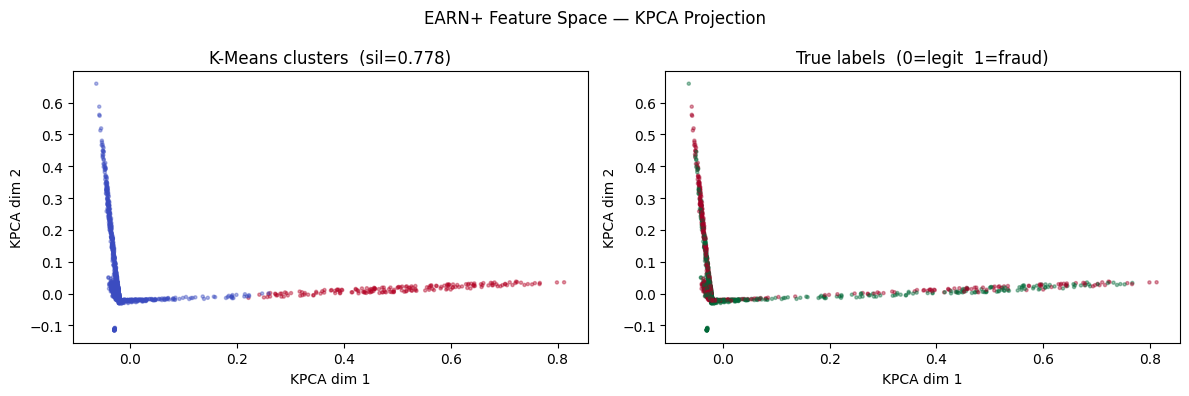

In [19]:
# ── Cell 10: K-Means + Silhouette Validation ─────────────────────────────────
 
sample_size   = min(5000, len(Z_train_kpca))
idx           = np.random.choice(len(Z_train_kpca), sample_size, replace=False)
Z_sample      = Z_train_kpca[idx]
y_sample      = y_train[idx]
 
kmeans        = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(Z_sample)
 
sil_score_val = silhouette_score(Z_sample, cluster_labels)
ari           = adjusted_rand_score(y_sample, cluster_labels)
 
print(f"\nSilhouette Score   : {sil_score_val:.4f}  (target > 0.4)")
print(f"Adjusted Rand Index: {ari:.4f}  (target > 0.3)")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(Z_sample[:, 0], Z_sample[:, 1], c=cluster_labels,
                cmap='coolwarm', alpha=0.4, s=5)
axes[0].set_title(f'K-Means clusters  (sil={sil_score_val:.3f})')
axes[0].set_xlabel('KPCA dim 1'); axes[0].set_ylabel('KPCA dim 2')
 
axes[1].scatter(Z_sample[:, 0], Z_sample[:, 1], c=y_sample,
                cmap='RdYlGn', alpha=0.4, s=5)
axes[1].set_title('True labels  (0=legit  1=fraud)')
axes[1].set_xlabel('KPCA dim 1'); axes[1].set_ylabel('KPCA dim 2')
 
plt.suptitle('EARN+ Feature Space — KPCA Projection', fontsize=12)
plt.tight_layout()
plt.savefig('../data/kpca_clusters.png')
plt.show()

In [20]:
# ── Cell 11: Save Everything for Notebook 4 ──────────────────────────────────
 
os.makedirs('../data',   exist_ok=True)
os.makedirs('../models', exist_ok=True)
 
np.save('../data/Z_train_earn.npy', Z_train_kpca)
np.save('../data/Z_test_earn.npy',  Z_test_kpca)
np.save('../data/y_train.npy',      y_train)
np.save('../data/y_test.npy',       y_test)
 
torch.save(ae_model.state_dict(), '../models/autoencoder.pt')
torch.save(resnet.state_dict(),   '../models/resnet_extractor.pt')
joblib.dump(kpca,                  '../models/kernel_pca.pkl')
 
print("\n✓ Saved to disk:")
print("   data/Z_train_earn.npy   ← EARN+ features for Notebook 4")
print("   data/Z_test_earn.npy")
print("   data/y_train.npy  /  y_test.npy")
print("   models/autoencoder.pt")
print("   models/resnet_extractor.pt")
print("   models/kernel_pca.pkl")
print(f"\nFinal feature shape  → Notebook 4: {Z_train_kpca.shape}")
print(f"Silhouette Score     : {sil_score_val:.4f}")


✓ Saved to disk:
   data/Z_train_earn.npy   ← EARN+ features for Notebook 4
   data/Z_test_earn.npy
   data/y_train.npy  /  y_test.npy
   models/autoencoder.pt
   models/resnet_extractor.pt
   models/kernel_pca.pkl

Final feature shape  → Notebook 4: (329932, 50)
Silhouette Score     : 0.7784
